In [3]:
import sys
sys.path.append('/Users/akeow/Desktop/TEAMER HDPS/HDPSTeamer/TurboShipCostCalculator/')


import scipy as sp
import funcTidal
import funcRotor
import funcConstraint
import funcSimRotor
import funcLCOE
import funcMain
import constUnitConvert
import constGlobal
import constVessel

CONVERT = constUnitConvert.ConstantsUnitConversion()
GLOBAL = constGlobal.ConstantsGlobal()


This tutorial provide an example of performing python constrained minimization optimization.

First define the Simulation Condition
- the tidal data from NOAA buoy station `myStation`
- cut-in speed `Umin`
- if brake is used or not `withBrake`
- the Vessel properties `VESSEL`
- scaling factor for rated power helps with faster convergence `scalePrated = 1e3`

Then define the grid points for the brute force optimization. The variables are radiusm rated power, hub depth and number of turbine. It must be in the order minimum, maximum and timestep. 

Simulation Condition

In [4]:
myStation = "SEA0711"
Umin = None
withBrake = True
VESSEL = constVessel.FISH
scalePrated = 1.0e3

Load Tidal Data and Rotor Data

In [5]:
station = myStation
startdate = 20210901
rangeHr = 2 * 7 * 24
timestep = 0.2

Uinf, t, dMoor, buoyLatitude, buoyLongitude = funcTidal.loadTidal(station, startdate, rangeHr, timestep)
print(f"Mooring depth is {dMoor} [m].")

AlaskaCityLocationData = "/Users/akeow/Desktop/TEAMER HDPS/HDPSTeamer/TurboShipCostCalculator/AlaskaCityLatLong.txt"
dCable, CityName = funcTidal.calCableLen(buoyLatitude, buoyLongitude, AlaskaCityLocationData)
cable_length_miles = dCable * CONVERT.m2mile
print(f"Cable length is {round(cable_length_miles, 2)} miles and the closest city is {CityName}.")

AeroDynFolderPath = "/Users/akeow/Desktop/TEAMER HDPS/HDPSTeamer/TurboShipCostCalculator/Original_MHKF1_ARLScaled_20Sections_5ms_VariedPitch_Cp/"
myTSRmax = 10.0
myTSRmin = 0.0

CpFunc, CtFunc, CpminFunc, spanRatio, CpOpt, TSROpt = funcRotor.loadRotorSurfaces(AeroDynFolderPath, myTSRmax, myTSRmin)
bladeVolume, baseMass, baseRadius, bladeCoordinate = funcRotor.estimateRotorMass(AeroDynFolderPath)


/Users/akeow/opt/anaconda3/envs/TeamerHDPS/lib/python3.11/site-packages/urllib3/connectionpool.py:1103: InsecureRequestWarning: Unverified HTTPS request is being made to host 'proxy.sandia.gov'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/Users/akeow/opt/anaconda3/envs/TeamerHDPS/lib/python3.11/site-packages/urllib3/connectionpool.py:1103: InsecureRequestWarning: Unverified HTTPS request is being made to host 'proxy.sandia.gov'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


Mooring depth is 35.4 [m].
Cable length is 2.2 miles and the closest city is Ketchikan.


Print Simulation Condition

In [6]:
funcMain.printSimulationDetails(Umin, withBrake, scalePrated, VESSEL, station, startdate, rangeHr, timestep, Uinf, dMoor, cable_length_miles, CityName)

Simulation Conditions:
Minimum Flow Speed (Umin): None
Brake Enabled: Yes
Scale of Prated: 1000.0 W
Vessel Type: Fish

Tidal Simulation Details:
Station: SEA0711
Start Date: September 01, 2021
Simulation Range: 336 hours
Timestep: 0.2 seconds
Minimum Flow from Uinf: 0.00 m/s
Maximum Flow from Uinf: 0.80 m/s
Mean Flow from Uinf: 0.37 m/s
Mooring Depth: 35.4 meters
Cable Length: 2.20 miles
Closest City: Ketchikan


Run Minimization
- Use brute force output as initial condition for faster convergence

In [11]:

initial_x = [3.2, 3.0e3/scalePrated, 4.0, 4.0]
bounds = [(0.8, 4.0), (1.0e3/scalePrated, 10.0e3/scalePrated), (1.0, 6.0), (1.0, 6.0)]


# Define the constraints
constraints = [
    {'type': 'ineq', 'fun': funcMain.constraintFuncMinimize1Pitch, 'args': (dMoor, Uinf, t, CpFunc, CtFunc, CpOpt, TSROpt, baseRadius, baseMass, VESSEL, Umin, withBrake, scalePrated)},
    {'type': 'ineq', 'fun': funcMain.constraintFuncMinimizeCavitation, 'args': (dMoor, Uinf, t, CpFunc, CtFunc, CpOpt, TSROpt, baseRadius, baseMass, CpminFunc[0], spanRatio[0], Umin, withBrake, scalePrated)},
    {'type': 'ineq', 'fun': funcMain.constraintFuncMinimizeCavitation, 'args': (dMoor, Uinf, t, CpFunc, CtFunc, CpOpt, TSROpt, baseRadius, baseMass, CpminFunc[1], spanRatio[1], Umin, withBrake, scalePrated)},
    {'type': 'ineq', 'fun': funcMain.constraintFuncMinimizeCavitation, 'args': (dMoor, Uinf, t, CpFunc, CtFunc, CpOpt, TSROpt, baseRadius, baseMass, CpminFunc[2], spanRatio[2], Umin, withBrake, scalePrated)},
    {'type': 'ineq', 'fun': lambda x: x[2] - x[0]},
    {'type': 'ineq', 'fun': lambda x: dMoor - (x[0] + x[2])}
]


# rhobeg (perturbation step)
# disp(convergence message)
# maxiter (max number of iterations)
myoptions = {'rhobeg': 0.5, 'disp': True, 'maxiter': 1000}

Nfeval = 1

def callbackF(x):
    global Nfeval
    cost = funcMain.objectiveFuncMinimize(x, dCable, dMoor, Uinf, t, CpFunc, CtFunc, CpOpt, TSROpt, baseRadius, baseMass, VESSEL, Umin, withBrake, scalePrated)
    print("{0:4d} -- cost: {1: 0.4f} x: {2: 0.4f}   {3: 0.4f}   {4: 0.4f}   {5: 0.4f}".format(Nfeval, cost, x[0], x[1]*scalePrated, x[2], x[3]))

    Nfeval += 1

result = sp.optimize.minimize(
    funcMain.objectiveFuncMinimize,
    initial_x,
    method='cobyla',
    bounds=bounds,
    constraints=constraints,
    args=(dCable, dMoor, Uinf, t, CpFunc, CtFunc, CpOpt, TSROpt, baseRadius, baseMass, VESSEL, Umin, withBrake, scalePrated),
    tol=0.1,
    callback=callbackF,
    options=myoptions
)

print("Optimization result:", result)


LCOE is 1.0204 for Rr: 3.2000, Prated: 3000.0000, dHub: 4.0000, and #turbine: 4.0000
LCOE is 0.7921 for Rr: 3.7000, Prated: 3000.0000, dHub: 4.0000, and #turbine: 4.0000
   1 -- cost:  0.7921 x:  3.7000    3000.0000    4.0000    4.0000
LCOE is 0.7921 for Rr: 3.7000, Prated: 3000.0000, dHub: 4.0000, and #turbine: 4.0000
LCOE is 0.7920 for Rr: 3.7000, Prated: 3500.0000, dHub: 4.0000, and #turbine: 4.0000
   2 -- cost:  0.7920 x:  3.7000    3500.0000    4.0000    4.0000
LCOE is 0.7920 for Rr: 3.7000, Prated: 3500.0000, dHub: 4.0000, and #turbine: 4.0000
LCOE is 0.7920 for Rr: 3.7000, Prated: 3500.0000, dHub: 4.5000, and #turbine: 4.0000
   3 -- cost:  0.7920 x:  3.7000    3500.0000    4.5000    4.0000
LCOE is 0.7920 for Rr: 3.7000, Prated: 3500.0000, dHub: 4.5000, and #turbine: 4.0000
LCOE is 0.7920 for Rr: 3.7000, Prated: 3500.0000, dHub: 4.0000, and #turbine: 4.0000
   4 -- cost:  0.7920 x:  3.7000    3500.0000    4.0000    4.5000
LCOE is 0.7920 for Rr: 3.7000, Prated: 3500.0000, dHub: 

Plot Result at Optimal Point

Running rotor simulation for Radius = 3.3707328828670624, Prated = 2627.0051419868864, dHub = 3.370732882867063.


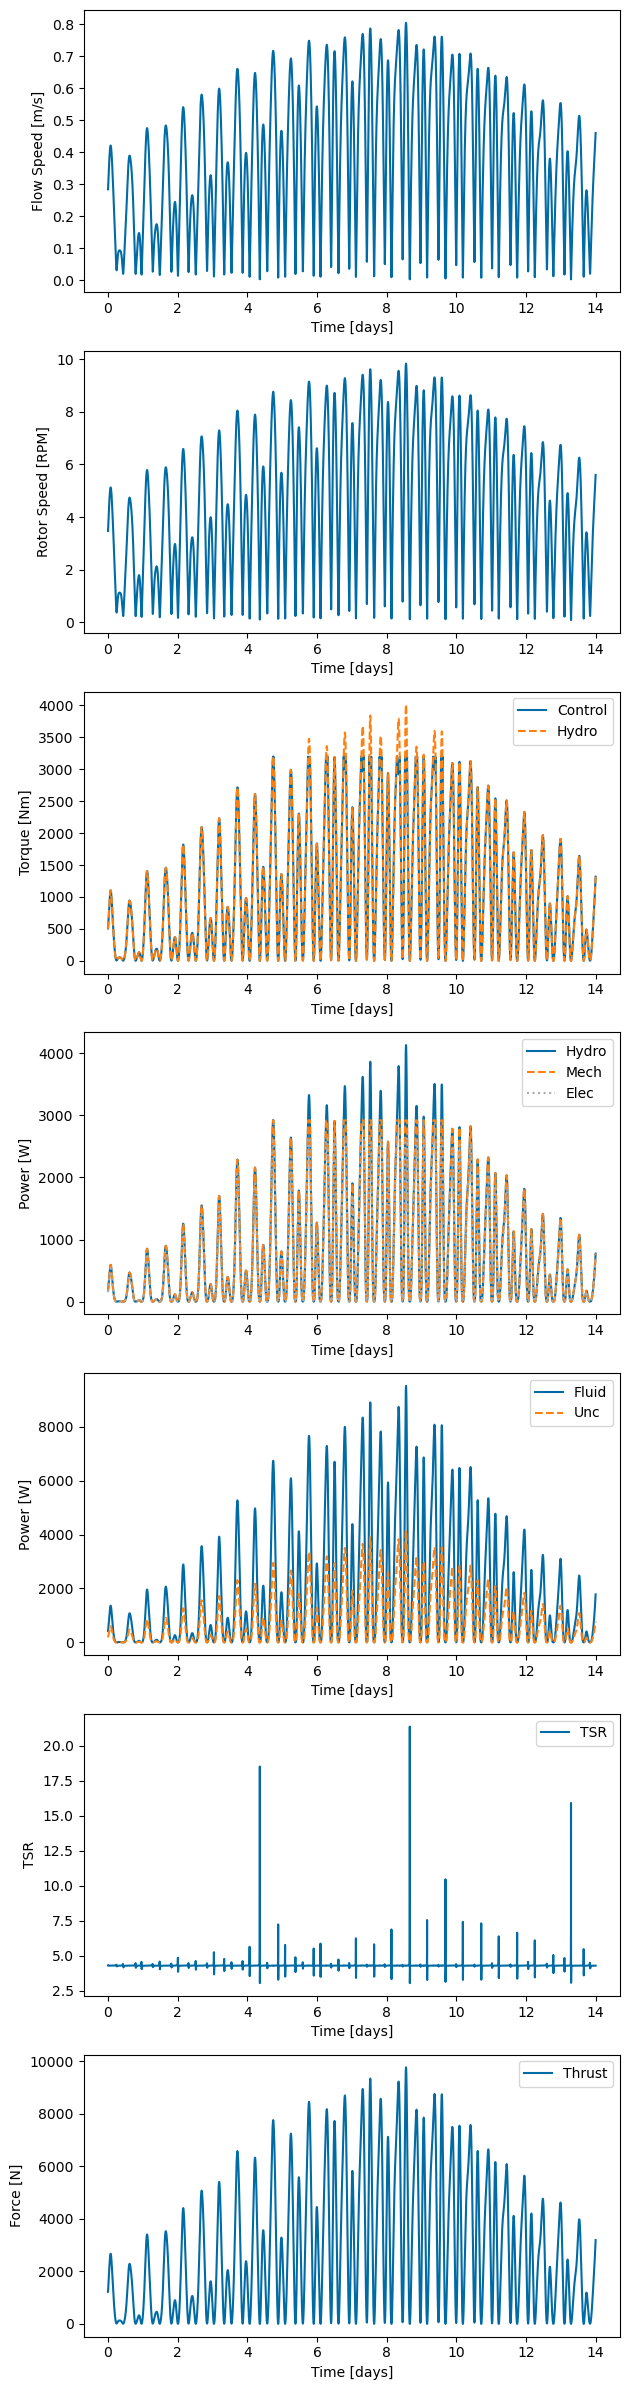

In [12]:
result.x[1] = result.x[1]*scalePrated
Radius, Prated, dHub, NumTurbine = result.x

w, Tc, Pmech, Pelec, Phydro, Pfluid, Punc, TSR, Ft, Th = funcSimRotor.simRotor(Radius, Prated, dHub, dMoor, Uinf, t, CpFunc, CtFunc, CpOpt, TSROpt, baseRadius, baseMass, Umin, withBrake)

Uinf_update = funcTidal.flowAtDepth(Uinf, Radius, dHub, dMoor)
F_vessel_thrust = funcConstraint.calForceMoorThrustFunc(Uinf_update, VESSEL)
F_turbine_thrust = funcSimRotor.calForceThrustFunc(Radius, Uinf_update, CtFunc(TSR))

LCOE, CostBreakdown = funcLCOE.calculate_cost(Radius, Prated, NumTurbine, dCable, dMoor, F_vessel_thrust, F_turbine_thrust, Pelec, t)
CostBreakdown

funcSimRotor.plotTimeDomainResult(Uinf, t, w, Tc, Pmech, Pelec, Phydro, Pfluid, Punc, TSR, Ft, Th, station, startdate, VESSEL, Umin, withBrake)


Use build in function to vidualise vessel pitch constraint

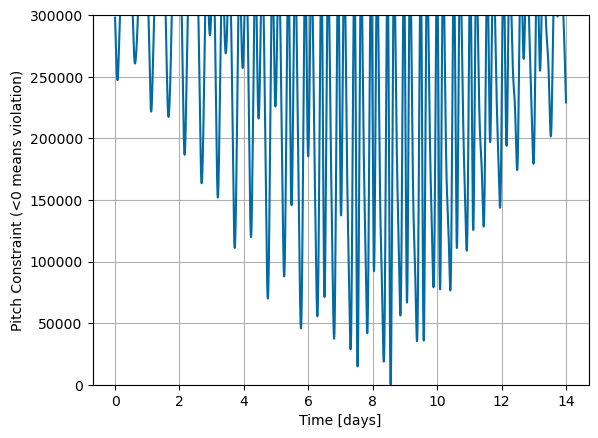

In [19]:
ylim = [-0.1, 300000] # for plotting graph
funcConstraint.plotPitchCon(Radius, dHub, dMoor, Uinf, CtFunc, TSR, VESSEL, NumTurbine, t, ylim)


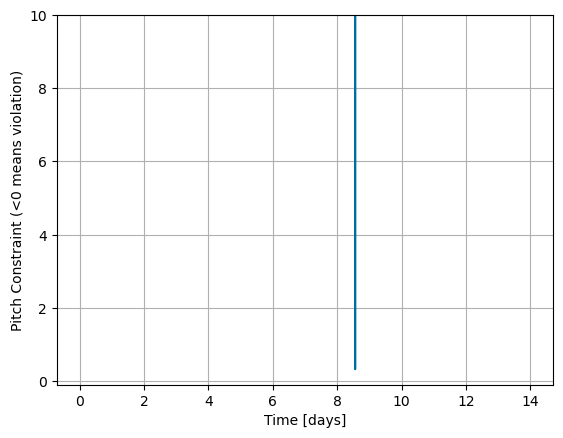

In [15]:

ylim = [-0.1, 10] # for plotting graph
funcConstraint.plotPitchCon(Radius, dHub, dMoor, Uinf, CtFunc, TSR, VESSEL, NumTurbine, t, ylim)


Use build in function to vidualise cavitation constraint

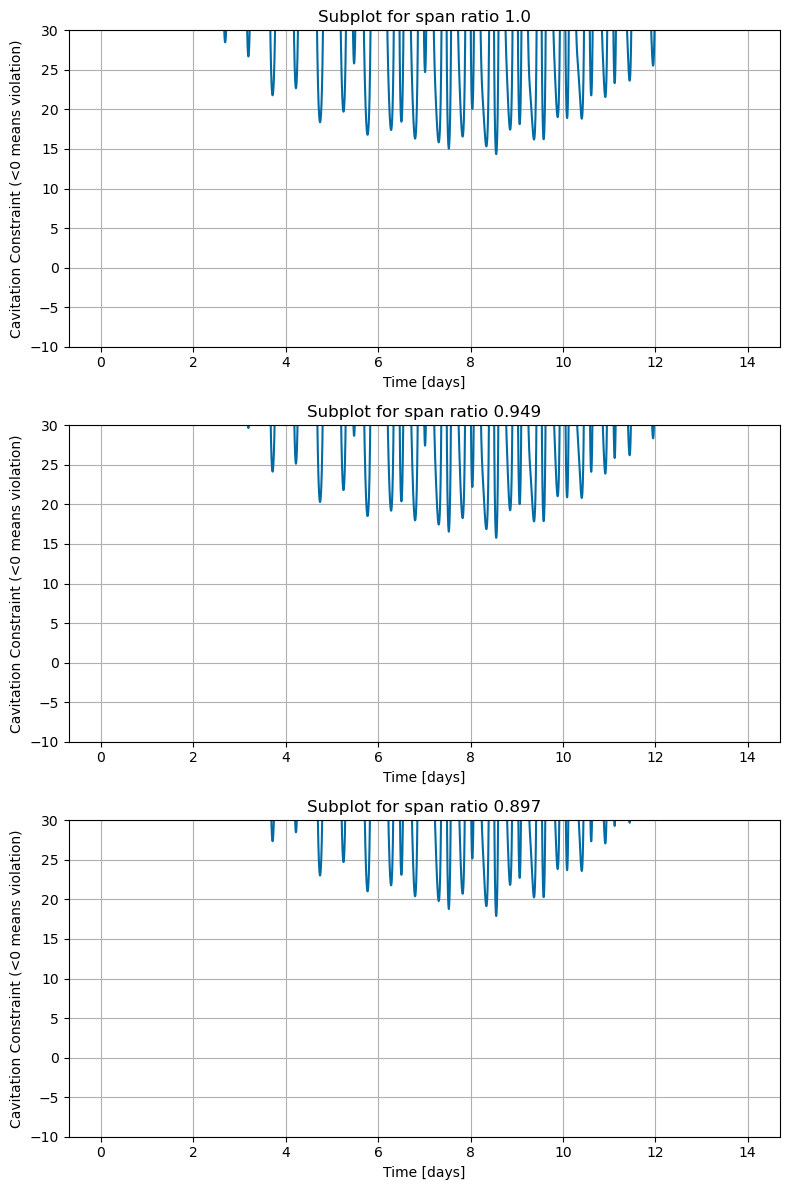

In [10]:
import importlib
importlib.reload(funcConstraint)
ylim = [-10, 30] # for plotting graph

funcConstraint.plotCavitationCon(Radius, dHub, dMoor, Uinf, w, TSR, CpminFunc, spanRatio, t, ylim)